# LDA Topic Modeling

In [17]:
import gensim
from gensim import corpora
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # To ignore all warnings that arise here to enhance clarity
 
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel
from sklearn.metrics import silhouette_score

In [18]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk import word_tokenize, pos_tag
from nltk.stem import WordNetLemmatizer

## Data cleaning

In [19]:
file_path = "/Users/chentangying/Desktop/sem2/ml/proj/china_paragraphs.xlsx"


df = pd.read_excel(file_path)
china_paragraphs = df['china_paragraph']

wordnet_lemmatizer = WordNetLemmatizer()
sr = set(stopwords.words('english')) 

def tokenize(sentence):
    sentence = re.sub(r'\s+', ' ', sentence)
    sentence = sentence.replace("United", "America").replace("States", "America").replace("American", "America").replace("economic","economy").replace("Chinese","China").replace("freedom","free").replace("viet-nam","vietnam")
    token_words = word_tokenize(sentence)
    token_words = pos_tag(token_words)   
    return token_words

wordnet_lematizer = WordNetLemmatizer()

def stem(token_words):
    words_lematizer = []
    for word, tag in token_words:
        if tag.startswith('NN'):
            word_lematizer =  wordnet_lematizer.lemmatize(word, pos='n')  # n代表名词
        elif tag.startswith('VB'): 
            word_lematizer =  wordnet_lematizer.lemmatize(word, pos='v')   # v代表动词
        elif tag.startswith('JJ'): 
            word_lematizer =  wordnet_lematizer.lemmatize(word, pos='a')   # a代表形容词
        elif tag.startswith('R'): 
            word_lematizer =  wordnet_lematizer.lemmatize(word, pos='r')   # r代表代词
        else: 
            word_lematizer =  wordnet_lematizer.lemmatize(word)
        words_lematizer.append(word_lematizer)
    return words_lematizer

sr = set(stopwords.words('english'))
custom_stopwords = {'we','i','I','the','and','q','s','but',"'s",'u','go','say','class=',"_x000d_","/span",'mr.','p','p1','s1','br','must','like','make','think','would','many','great','come','want','deal','good',"n\'t",'let','play',"also",'nbsp',"nafta",'q.','year','one','two','new','take','know','get','give','lot','thing','house','give','need','america','economy','every','help','last','country'}

combined_stopwords = sr.union(custom_stopwords)

def delete_stopwords(token_words):
    cleaned_words = [word.lower() for word in token_words if word.lower() not in combined_stopwords]
    return cleaned_words

def is_number(s):
    try:
        float(s)
        return True
    except ValueError:
        pass
 
    try:
        import unicodedata
        unicodedata.numeric(s)
        return True
    except (TypeError, ValueError):
        pass
 
    return False

characters = [' ',',', '.','DBSCAN', ':', ';', '?', '(', ')', '[', ']', '&', '!', '*', '@', '#', '$', '%','-','...','^','{','}', '‘', '’','“','”','<','>','-','--','——',"—","\'\'"]
def delete_characters(token_words):
    words_list = [word for word in token_words if word not in characters and not is_number(word)]
    return words_list

def to_lower(token_words):
    words_lists = [x.lower() for x in token_words]
    return words_lists

def pre_process(text):
    token_words = tokenize(text)
    token_words = stem(token_words)
    token_words = delete_stopwords(token_words)
    token_words = delete_characters(token_words)
    token_words = to_lower(token_words)
    return token_words

# main
if __name__ == '__main__':
    data_set = []  

    for paragraph in china_paragraphs:
        processed_paragraph = pre_process(paragraph)
        if processed_paragraph:  
            data_set.append(processed_paragraph)

    for item in data_set[:5]:  
        print(item)
    



['decision', 'force', 'nations', 'strive', 'limit', 'conflict', 'possible', 'see', 'conflict', 'korea', 'extend', 'try', 'prevent', 'world', 'war—not', 'start', 'best', 'way', 'plain', 'free', 'continue', 'resist', 'attack', 'may', 'ask', 'ca', 'step', 'punish', 'aggressor', 'bomb', 'manchuria', 'china', 'assist', 'china', 'nationalist', 'troop', 'land', 'mainland', 'china', 'run', 'grave', 'risk', 'start', 'general', 'war', 'happen', 'bring', 'exact', 'situation', 'try', 'prevent', 'become', 'entangled', 'vast', 'conflict', 'continent', 'asia', 'task', 'become', 'immeasurably', 'difficult', 'world', 'suit', 'ambition', 'kremlin', 'military', 'force', 'commit', 'full-scale', 'war', 'red', 'china']
['see', 'conflict', 'korea', 'extend', 'try', 'prevent', 'world', 'war—not', 'start', 'best', 'way', 'plain', 'free', 'continue', 'resist', 'attack', 'may', 'ask', 'ca', 'step', 'punish', 'aggressor', 'bomb', 'manchuria', 'china', 'assist', 'china', 'nationalist', 'troop', 'land', 'mainland',

## Dictionary

In [20]:
dictionary = corpora.Dictionary(data_set)  
corpus = [dictionary.doc2bow(text) for text in data_set] 

## Calculate perplexity and silhouette

[(0, '0.024*"china" + 0.011*"world" + 0.010*"people" + 0.006*"nation" + 0.006*"president" + 0.005*"free" + 0.005*"peace" + 0.004*"work"')]
Perplexity: -7.585734791975212
Silhouette Score cannot be computed; only one cluster found.
Coherence Score: 0.2687072980430758
[(0, '0.022*"china" + 0.008*"president" + 0.007*"billion" + 0.006*"people" + 0.006*"trade" + 0.005*"world" + 0.005*"time" + 0.005*"job"'), (1, '0.026*"china" + 0.015*"world" + 0.014*"people" + 0.009*"nation" + 0.007*"peace" + 0.006*"free" + 0.006*"asia" + 0.005*"war"')]
Perplexity: -7.563690413476618
Silhouette Score: 0.8384981482051045
Coherence Score: 0.3700048607001865
[(0, '0.018*"china" + 0.013*"world" + 0.009*"nation" + 0.007*"free" + 0.007*"nuclear" + 0.007*"work" + 0.006*"peace" + 0.006*"continue"'), (1, '0.016*"china" + 0.006*"president" + 0.006*"people" + 0.006*"billion" + 0.005*"job" + 0.005*"tariff" + 0.004*"dollar" + 0.004*"happen"'), (2, '0.034*"china" + 0.017*"people" + 0.012*"world" + 0.009*"president" + 0.0

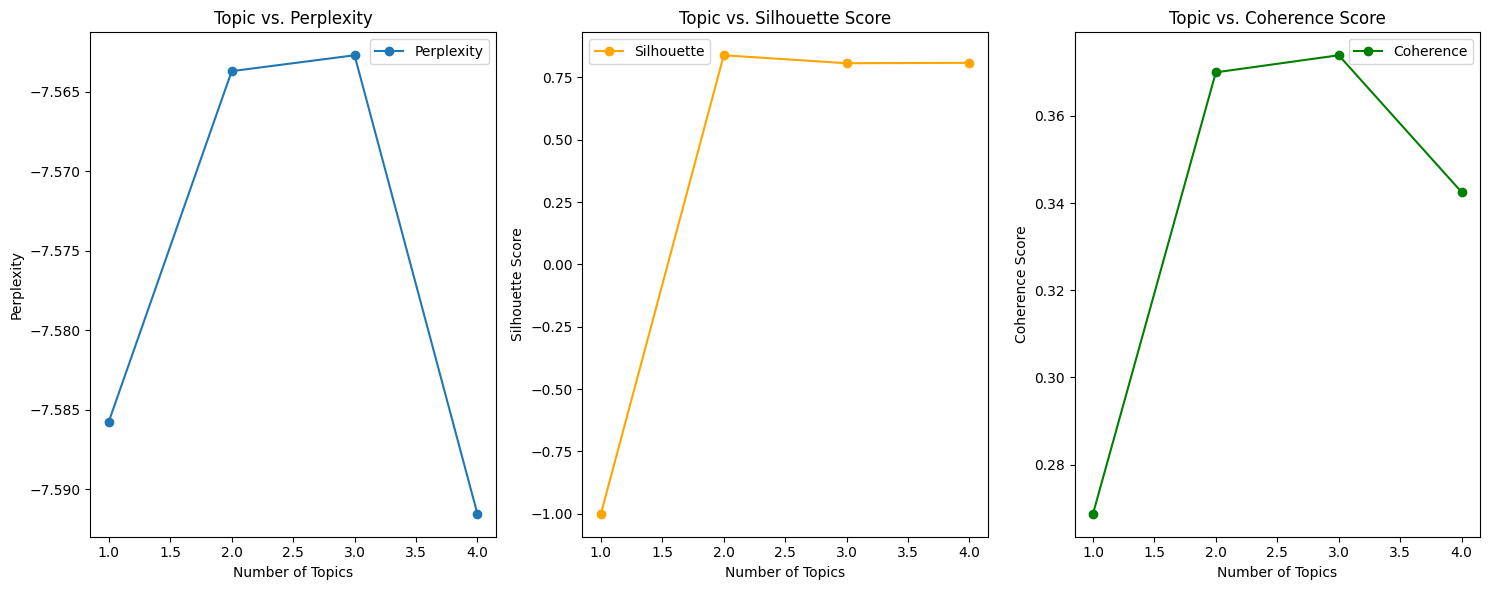

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import LdaModel, CoherenceModel
from sklearn.metrics import silhouette_score

def perplexity_silhouette_coherence(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=30)

    print(ldamodel.print_topics(num_topics=num_topics, num_words=8))
    
    # perplexity
    perplexity_value = ldamodel.log_perplexity(corpus)
    print(f"Perplexity: {perplexity_value}")

    doc_topics = ldamodel.get_document_topics(corpus)
    
    # topic
    topic_distribution = np.zeros((len(corpus), num_topics))
    for i, topics in enumerate(doc_topics):
        for topic, prob in topics:
            topic_distribution[i, topic] = prob

    # silhouette
    labels = np.argmax(topic_distribution, axis=1)
    if len(set(labels)) > 1:
        silhouette_avg = silhouette_score(topic_distribution, labels)
        print(f"Silhouette Score: {silhouette_avg}")
    else:
        silhouette_avg = -1  
        print("Silhouette Score cannot be computed; only one cluster found.")

    # coherence
    coherence_model = CoherenceModel(model=ldamodel, texts=data_set, dictionary=dictionary, coherence='c_v')
    coherence_value = coherence_model.get_coherence()
    print(f"Coherence Score: {coherence_value}")

    return perplexity_value, silhouette_avg, coherence_value

# main
x = range(1, 5)
perplexity_values = []
silhouette_values = []
coherence_values = []

for i in x:
    perplexity_value, silhouette_avg, coherence_value = perplexity_silhouette_coherence(i)
    perplexity_values.append(perplexity_value)
    silhouette_values.append(silhouette_avg)
    coherence_values.append(coherence_value)

# plot-perplexity
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.plot(x, perplexity_values, marker='o', label='Perplexity')
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity')
plt.title('Topic vs. Perplexity')
plt.legend()

# plot-silhouette
plt.subplot(1, 3, 2)
plt.plot(x, silhouette_values, marker='o', label='Silhouette', color='orange')
plt.xlabel('Number of Topics')
plt.ylabel('Silhouette Score')
plt.title('Topic vs. Silhouette Score')
plt.legend()

# plot-cohernece
plt.subplot(1, 3, 3)
plt.plot(x, coherence_values, marker='o', label='Coherence', color='green')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score')
plt.title('Topic vs. Coherence Score')
plt.legend()

plt.tight_layout()
plt.show()

## Select Topic

In [7]:
dictionary = corpora.Dictionary(data_set)
corpus = [dictionary.doc2bow(text) for text in data_set]
 
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=3, passes = 30,random_state=1)
topic_list=lda.print_topics()
print(topic_list)
 
for i in lda.get_document_topics(corpus)[:]:
    listj=[]
    for j in i:
        listj.append(j[1])
    bz=listj.index(max(listj))
    print(i[bz][0])


[(0, '0.028*"china" + 0.009*"billion" + 0.009*"job" + 0.008*"world" + 0.007*"work" + 0.006*"people" + 0.006*"build" + 0.006*"dollar" + 0.006*"trade" + 0.006*"right"'), (1, '0.019*"china" + 0.014*"world" + 0.012*"people" + 0.008*"nation" + 0.007*"peace" + 0.006*"free" + 0.006*"power" + 0.005*"asia" + 0.005*"nuclear" + 0.005*"continue"'), (2, '0.031*"china" + 0.014*"people" + 0.008*"president" + 0.008*"world" + 0.006*"republic" + 0.006*"government" + 0.006*"relation" + 0.004*"trade" + 0.004*"important" + 0.004*"war"')]
2
2
2
1
2
1
1
1
1
1
1
1
1
1
1
1
2
1
2
2
2
2
1
1
2
1
1
0
2
1
1
1
1
1
2
2
1
1
2
2
2
2
0
1
1
1
0
1
1
1
2
0
2
1
0
2
1
1
2
1
1
1
1
1
1
2
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
2
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
1
2
2
2
2
1
1
1
2
2
2
2
2
2
1
1
1
1
2
2
2
2
2
2
2
2
1
1
1
1
1
2
1
1
1
2
0
2
2
0
1
0
1
1
0
1
1
1
1
1
1
1
0
2
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
1
1
0
0
0
0
1
1
1
0
1
1
1
0
0
1
1
0
0
0
0
0
1
1
0
0
1
1
2
0
0
0
0
0
0
0
0
1
1
0
0
0
1
1
0
0
1
1
1
0
1
1
1
1
0
1

In [8]:
import pyLDAvis.gensim

pyLDAvis.enable_notebook()
data = pyLDAvis.gensim.prepare(lda, corpus, dictionary)
pyLDAvis.display(data)